# EDA - BEA 2026 Shared Task: Vocabulary Difficulty Prediction

**Task:** Predict `GLMM_score` (vocabulary difficulty) for English learners from different L1 backgrounds (Spanish, German, Mandarin).

**Data columns:**
- `item_id` – Item identifier (parallel across L1s)
- `L1` – First language (`es`, `de`, `cn`)
- `en_target_word` – English target word
- `en_target_pos` – Part of speech
- `en_target_clue` – Partial-spelling clue
- `L1_source_word` – Corresponding L1 word
- `L1_context` – L1 contextualising prompt
- `GLMM_score` – Difficulty score (**lower = harder**)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)

BASE = Path(r"bea2026st")

# Load all train and dev sets
dfs = {}
for split in ["train", "dev"]:
    for lang in ["es", "de", "cn"]:
        path = BASE / "data" / split / lang / f"kvl_shared_task_{lang}_{split}.csv"
        dfs[(split, lang)] = pd.read_csv(path)

# Combine into single DataFrames
train = pd.concat([dfs[("train", l)] for l in ["es", "de", "cn"]], ignore_index=True)
dev = pd.concat([dfs[("dev", l)] for l in ["es", "de", "cn"]], ignore_index=True)
train["split"] = "train"
dev["split"] = "dev"
all_data = pd.concat([train, dev], ignore_index=True)

print(f"Train: {len(train):,} rows | Dev: {len(dev):,} rows | Total: {len(all_data):,} rows")
print(f"\nTrain by L1:\n{train['L1'].value_counts().to_string()}")
print(f"\nDev by L1:\n{dev['L1'].value_counts().to_string()}")

Train: 18,273 rows | Dev: 2,031 rows | Total: 20,304 rows

Train by L1:
L1
es    6091
de    6091
cn    6091

Dev by L1:
L1
es    677
de    677
cn    677


## 1. Data Overview

In [2]:
# Sample rows
train.head(10)

,item_id,L1,en_target_word,en_target_pos,en_target_clue,L1_source_word,L1_context,GLMM_score,split
0,1,es,span,noun,s___,lapso,El eclipse solar fue visible durante un breve ...,-3.264099,train
1,2,es,radically,adverb,r________,fundamentalmente,Los métodos nuevos son fundamentalmente difere...,-1.871782,train
2,3,es,supermarket,noun,s__________,supermercado,Vamos al supermercado y compramos todo lo que ...,2.733109,train
3,4,es,airplane,noun,a_______,avión,El avión despegó tres horas tarde.,0.054737,train
4,5,es,trying,adjective,t_____,difícil,"Es un tiempo muy difícil, sin ninguna duda.",-4.086776,train
5,6,es,racing,noun,r_____,carreras,¿Te puedes creer que se ha comprado un coche d...,-0.071782,train
6,7,es,sleep,verb,s____,dormir,Es importante dormir bien si estás enfermo.,3.682800,train
7,8,es,military,noun,m_______,ejército,El ejército no parecía nada contento con los c...,-0.086130,train
8,9,es,capacity,noun,c_______,cabida,La sala da cabida a dos mil personas.,-1.726756,train
9,10,es,cane,noun,c___,bastón,Siempre veras a mi abuelo caminando con su bastón,-0.837535,train


In [3]:
# Basic stats
print("=== Data types ===")
print(train.dtypes)
print("\n=== Missing values (train) ===")
print(train.isnull().sum())
print("\n=== Missing values (dev) ===")
print(dev.isnull().sum())
print("\n=== Descriptive stats (GLMM_score) ===")
train.groupby("L1")["GLMM_score"].describe().round(3)

=== Data types ===
item_id             int64
L1                    str
en_target_word        str
en_target_pos         str
en_target_clue        str
L1_source_word        str
L1_context            str
GLMM_score        float64
split                 str
dtype: object

=== Missing values (train) ===
item_id           0
L1                0
en_target_word    0
en_target_pos     0
en_target_clue    0
L1_source_word    0
L1_context        0
GLMM_score        0
split             0
dtype: int64

=== Missing values (dev) ===
item_id           0
L1                0
en_target_word    0
en_target_pos     0
en_target_clue    0
L1_source_word    0
L1_context        0
GLMM_score        0
split             0
dtype: int64

=== Descriptive stats (GLMM_score) ===


,count,mean,std,min,25%,50%,75%,max
L1,,,,,,,,
cn,6091.0,-0.034,1.668,-5.931,-1.245,-0.087,1.157,4.835
de,6091.0,-0.051,1.770,-6.498,-1.363,-0.040,1.278,4.323
es,6091.0,-0.032,1.862,-5.286,-1.347,-0.094,1.331,5.143


## 2. Target Variable Distribution (`GLMM_score`)

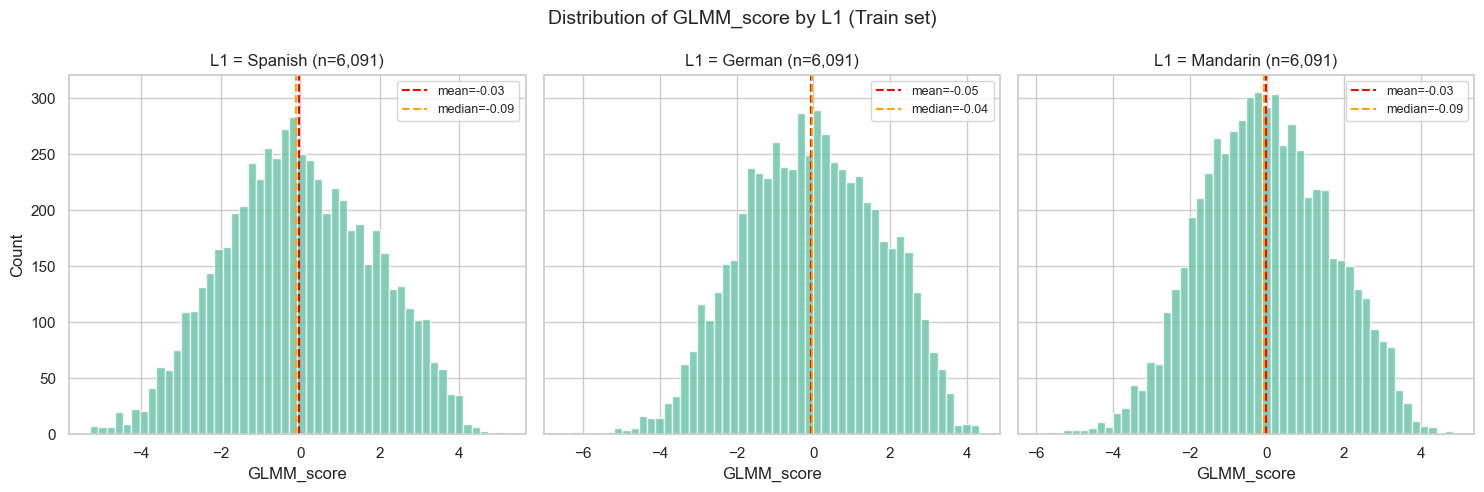

In [4]:
# Distribution of GLMM_score by L1
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
l1_labels = {"es": "Spanish", "de": "German", "cn": "Mandarin"}

for ax, lang in zip(axes, ["es", "de", "cn"]):
    subset = train[train["L1"] == lang]
    ax.hist(subset["GLMM_score"], bins=50, edgecolor="white", alpha=0.8)
    ax.set_title(f"L1 = {l1_labels[lang]} (n={len(subset):,})")
    ax.set_xlabel("GLMM_score")
    ax.axvline(subset["GLMM_score"].mean(), color="red", linestyle="--", label=f"mean={subset['GLMM_score'].mean():.2f}")
    ax.axvline(subset["GLMM_score"].median(), color="orange", linestyle="--", label=f"median={subset['GLMM_score'].median():.2f}")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Count")
fig.suptitle("Distribution of GLMM_score by L1 (Train set)", fontsize=14)
plt.tight_layout()
plt.show()

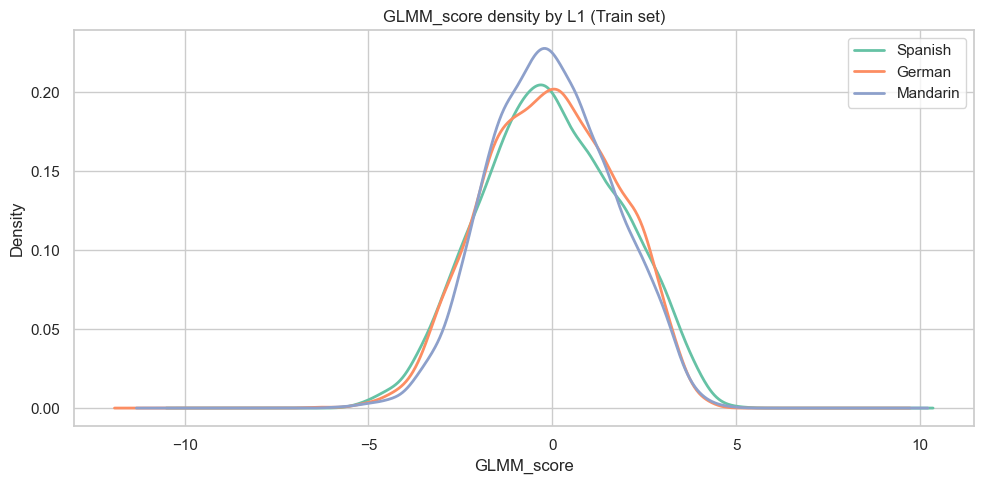

In [5]:
# Overlapping KDE plot
fig, ax = plt.subplots(figsize=(10, 5))
for lang, label in l1_labels.items():
    subset = train[train["L1"] == lang]
    subset["GLMM_score"].plot.kde(ax=ax, label=label, linewidth=2)

ax.set_xlabel("GLMM_score")
ax.set_title("GLMM_score density by L1 (Train set)")
ax.legend()
plt.tight_layout()
plt.show()

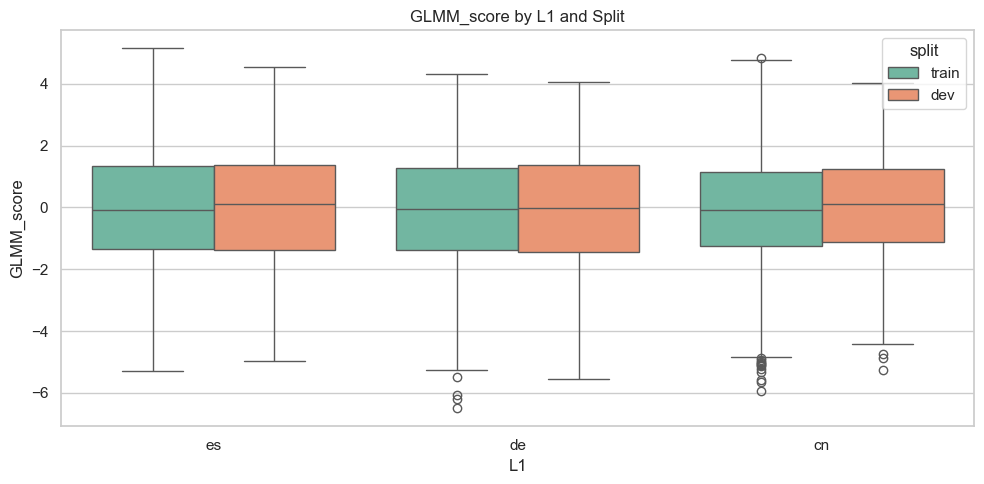

In [6]:
# Box plot: GLMM_score by L1 and split
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=all_data, x="L1", y="GLMM_score", hue="split", ax=ax)
ax.set_title("GLMM_score by L1 and Split")
plt.tight_layout()
plt.show()

## 3. Part of Speech Analysis

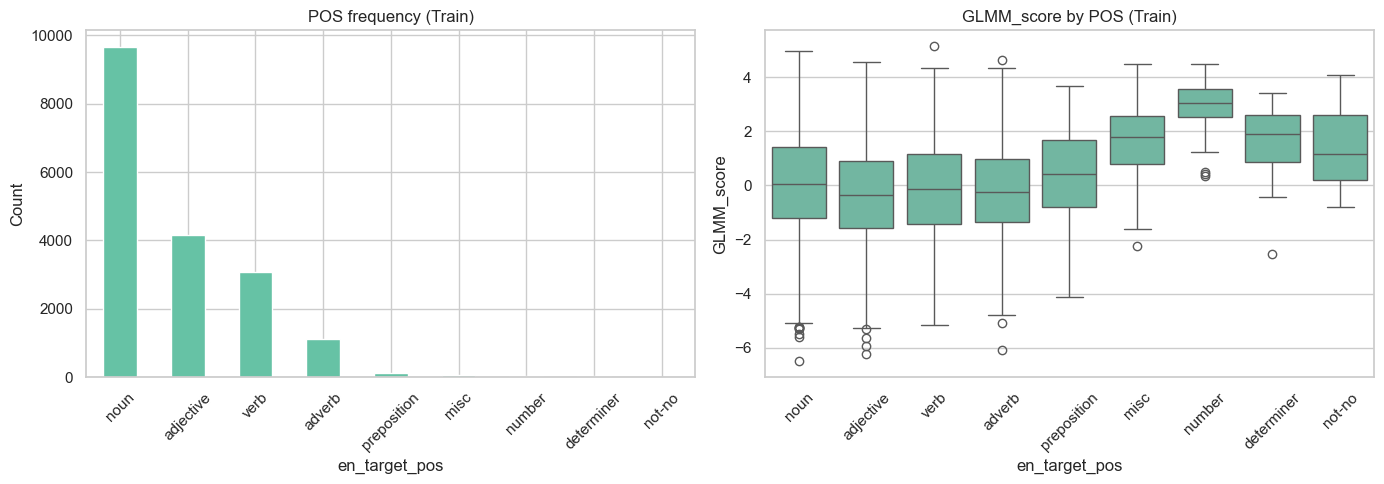

GLMM_score by POS:


,count,mean,std,min,max
en_target_pos,,,,,
noun,9660,0.099,1.756,-6.498,4.973
adjective,4158,-0.336,1.738,-6.213,4.557
verb,3090,-0.122,1.785,-5.142,5.143
adverb,1125,-0.170,1.708,-6.068,4.635
preposition,114,0.458,1.652,-4.118,3.659
misc,63,1.574,1.442,-2.233,4.465
number,39,2.848,1.029,0.355,4.484
determiner,21,1.504,1.461,-2.530,3.394
not-no,3,1.478,2.444,-0.800,4.060


In [7]:
# POS distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count by POS
pos_counts = train["en_target_pos"].value_counts()
pos_counts.plot.bar(ax=axes[0], edgecolor="white")
axes[0].set_title("POS frequency (Train)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# GLMM_score by POS
sns.boxplot(data=train, x="en_target_pos", y="GLMM_score", 
            order=pos_counts.index, ax=axes[1])
axes[1].set_title("GLMM_score by POS (Train)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Stats
print("GLMM_score by POS:")
train.groupby("en_target_pos")["GLMM_score"].agg(["count", "mean", "std", "min", "max"]).round(3).sort_values("count", ascending=False)

## 4. Word-Level Features

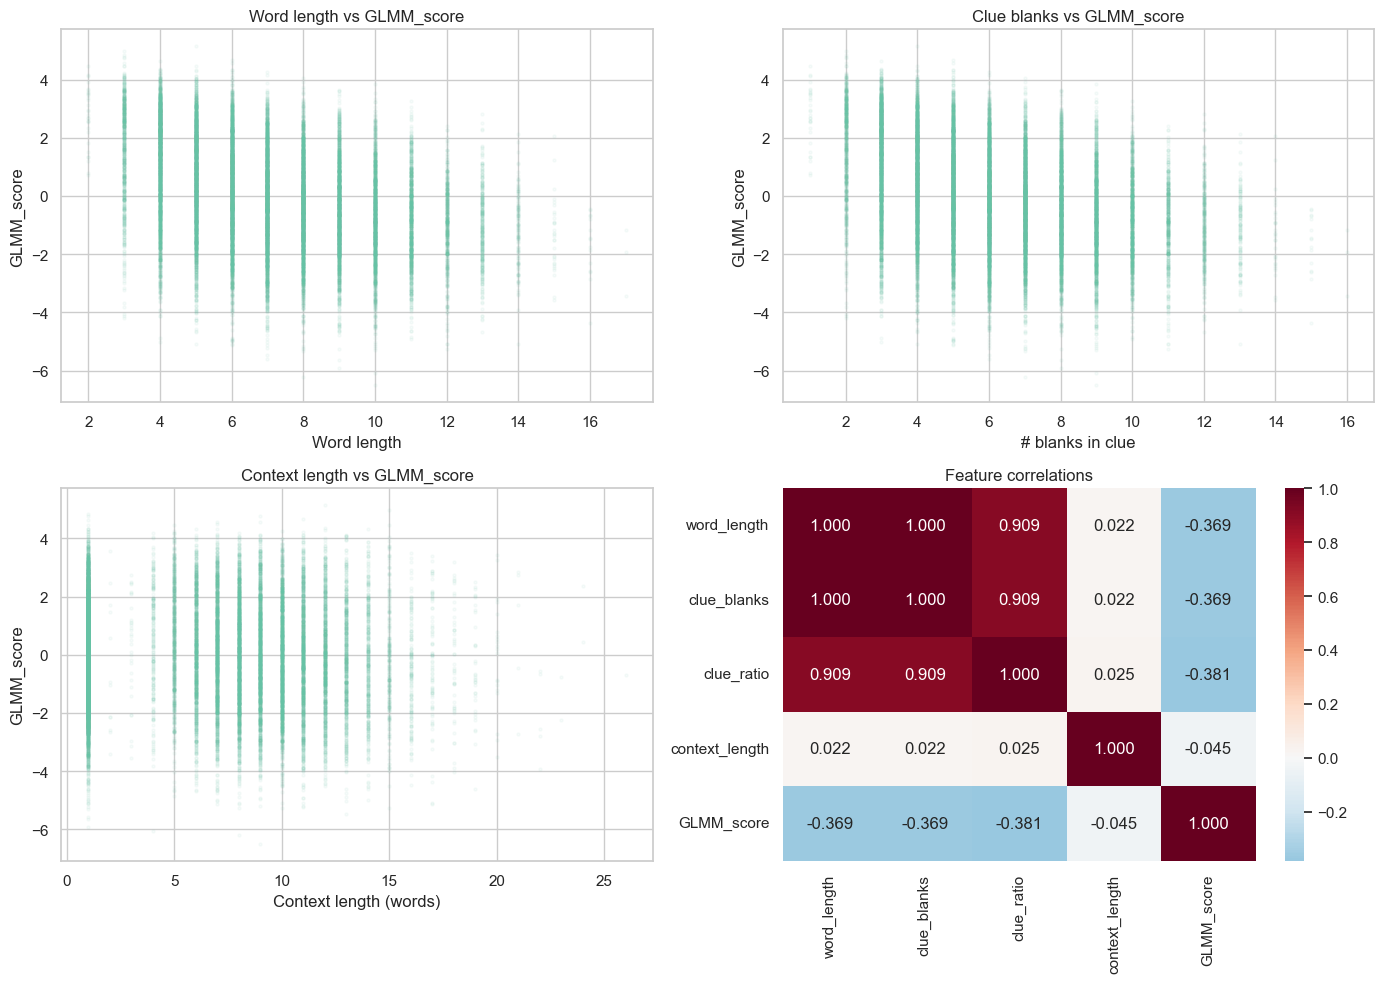

Correlations with GLMM_score:
clue_ratio       -0.381450
word_length      -0.368731
clue_blanks      -0.368731
context_length   -0.044775


In [8]:
# Engineered features
train["word_length"] = train["en_target_word"].str.len()
train["clue_blanks"] = train["en_target_clue"].str.count("_")
train["clue_ratio"] = train["clue_blanks"] / train["word_length"]  # proportion hidden
train["context_length"] = train["L1_context"].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Word length vs GLMM_score
axes[0, 0].scatter(train["word_length"], train["GLMM_score"], alpha=0.05, s=5)
axes[0, 0].set_xlabel("Word length")
axes[0, 0].set_ylabel("GLMM_score")
axes[0, 0].set_title("Word length vs GLMM_score")

# Clue blanks vs GLMM_score
axes[0, 1].scatter(train["clue_blanks"], train["GLMM_score"], alpha=0.05, s=5)
axes[0, 1].set_xlabel("# blanks in clue")
axes[0, 1].set_ylabel("GLMM_score")
axes[0, 1].set_title("Clue blanks vs GLMM_score")

# Context length vs GLMM_score
axes[1, 0].scatter(train["context_length"], train["GLMM_score"], alpha=0.05, s=5)
axes[1, 0].set_xlabel("Context length (words)")
axes[1, 0].set_ylabel("GLMM_score")
axes[1, 0].set_title("Context length vs GLMM_score")

# Correlation heatmap of numeric features
numeric_cols = ["word_length", "clue_blanks", "clue_ratio", "context_length", "GLMM_score"]
corr = train[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Feature correlations")

plt.tight_layout()
plt.show()

print("Correlations with GLMM_score:")
print(corr["GLMM_score"].drop("GLMM_score").sort_values().to_string())

## 5. Cross-L1 Comparison (Parallel Items)

Parallel items across all 3 L1s: 6,091

Correlation between L1 scores:
L1     cn     de     es
L1                     
cn  1.000  0.662  0.634
de  0.662  1.000  0.684
es  0.634  0.684  1.000


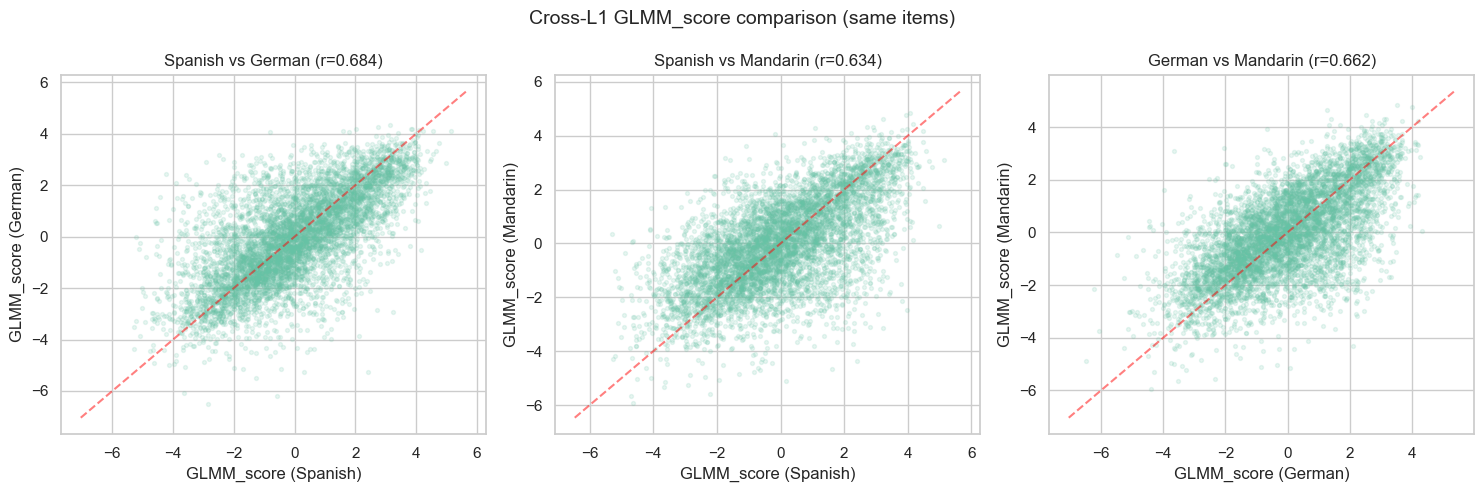

In [9]:
# Pivot to compare GLMM_score across L1s for same items
pivot = train.pivot_table(index="item_id", columns="L1", values="GLMM_score")
pivot = pivot.dropna()

print(f"Parallel items across all 3 L1s: {len(pivot):,}")
print(f"\nCorrelation between L1 scores:")
print(pivot.corr().round(3))

# Scatter matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [("es", "de"), ("es", "cn"), ("de", "cn")]
for ax, (l1, l2) in zip(axes, pairs):
    ax.scatter(pivot[l1], pivot[l2], alpha=0.15, s=8)
    ax.set_xlabel(f"GLMM_score ({l1_labels[l1]})")
    ax.set_ylabel(f"GLMM_score ({l1_labels[l2]})")
    r = pivot[l1].corr(pivot[l2])
    ax.set_title(f"{l1_labels[l1]} vs {l1_labels[l2]} (r={r:.3f})")
    # Identity line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, "r--", alpha=0.5)

plt.suptitle("Cross-L1 GLMM_score comparison (same items)", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Hardest and Easiest Words

In [10]:
# Top 10 hardest and easiest words per L1 (lower GLMM = harder)
for lang in ["es", "de", "cn"]:
    subset = train[train["L1"] == lang].sort_values("GLMM_score")
    print(f"\n{'='*60}")
    print(f"L1 = {l1_labels[lang]}")
    print(f"{'='*60}")
    print(f"\n🔴 10 HARDEST words (lowest GLMM_score):")
    print(subset[["en_target_word", "en_target_pos", "GLMM_score"]].head(10).to_string(index=False))
    print(f"\n🟢 10 EASIEST words (highest GLMM_score):")
    print(subset[["en_target_word", "en_target_pos", "GLMM_score"]].tail(10).to_string(index=False))


L1 = Spanish

🔴 10 HARDEST words (lowest GLMM_score):
en_target_word en_target_pos  GLMM_score
    systematic     adjective   -5.286114
     testament          noun   -5.271041
       analogy          noun   -5.216882
    projection          noun   -5.215601
       driving     adjective   -5.121635
        affirm          verb   -5.094026
    analytical     adjective   -5.080692
          shed          verb   -5.023753
    positivity          noun   -5.022154
        reason          verb   -4.996787

🟢 10 EASIEST words (highest GLMM_score):
en_target_word en_target_pos  GLMM_score
          hour          noun    4.368442
            no          misc    4.465405
         radio          noun    4.467880
           two        number    4.484412
        german     adjective    4.556840
           sun          noun    4.566609
        orange          noun    4.662359
           zoo          noun    4.761405
           jet          noun    4.972895
         dance          verb    5.143118



## 7. Baseline Results Overview

 track split              model L1     rmse  pearson
closed   dev baseline_closed_cn cn 1.174847 0.735527
closed   dev baseline_closed_de de 1.328255 0.753030
closed   dev baseline_closed_es es 1.356922 0.748421
  open   dev   baseline_open_xx es 1.206084 0.787306
  open   dev   baseline_open_xx de 1.148666 0.800390
  open   dev   baseline_open_xx cn 1.021396 0.804240


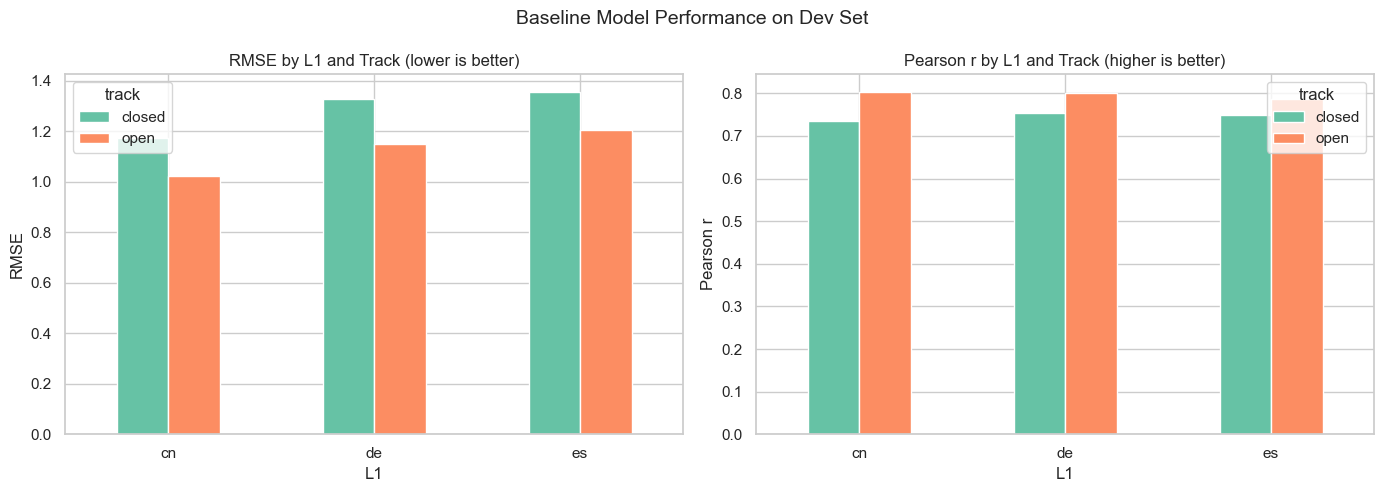

In [11]:
# Load and visualize baseline results
results = pd.read_csv(BASE / "results" / "results_summary_dev.csv")
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
results_pivot = results.pivot(index="L1", columns="track", values="rmse")
results_pivot.plot.bar(ax=axes[0], edgecolor="white")
axes[0].set_title("RMSE by L1 and Track (lower is better)")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=0)

# Pearson comparison
results_pivot_p = results.pivot(index="L1", columns="track", values="pearson")
results_pivot_p.plot.bar(ax=axes[1], edgecolor="white")
axes[1].set_title("Pearson r by L1 and Track (higher is better)")
axes[1].set_ylabel("Pearson r")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Baseline Model Performance on Dev Set", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Prediction Error Analysis

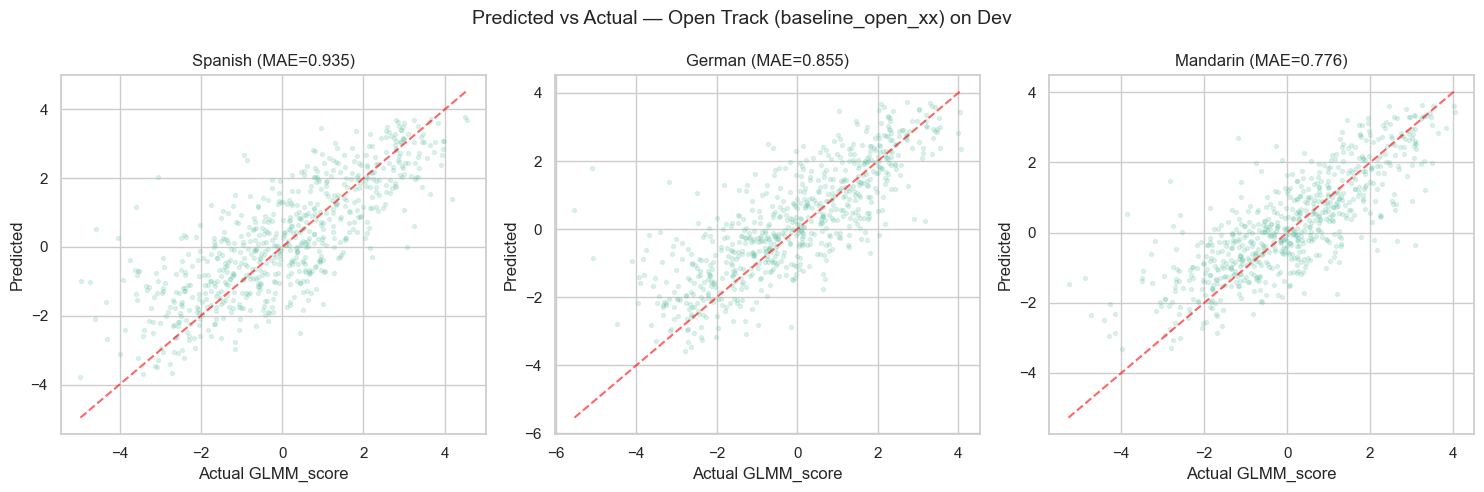

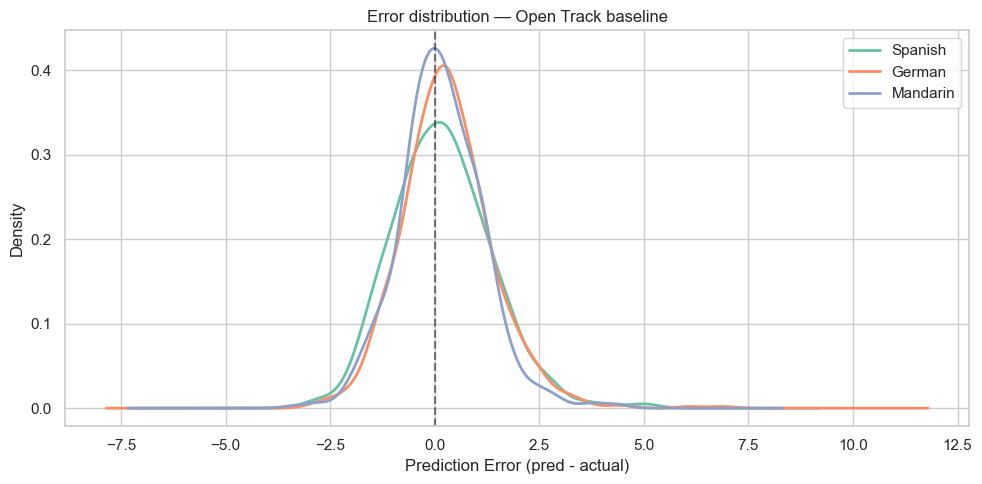

In [12]:
# Compare predictions vs actual (Open track - best model)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, lang in zip(axes, ["es", "de", "cn"]):
    # Load predictions and ground truth
    preds = pd.read_csv(BASE / "predictions" / "open" / "dev" / lang / "baseline_open_xx_preds.csv")
    actual = pd.read_csv(BASE / "data" / "dev" / lang / f"kvl_shared_task_{lang}_dev.csv")
    
    merged = actual.merge(preds, on="item_id")
    merged["error"] = merged["prediction"] - merged["GLMM_score"]
    
    ax.scatter(merged["GLMM_score"], merged["prediction"], alpha=0.2, s=8)
    lims = [merged[["GLMM_score", "prediction"]].min().min(), 
            merged[["GLMM_score", "prediction"]].max().max()]
    ax.plot(lims, lims, "r--", alpha=0.6)
    ax.set_xlabel("Actual GLMM_score")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{l1_labels[lang]} (MAE={merged['error'].abs().mean():.3f})")

plt.suptitle("Predicted vs Actual — Open Track (baseline_open_xx) on Dev", fontsize=14)
plt.tight_layout()
plt.show()

# Error distribution
fig, ax = plt.subplots(figsize=(10, 5))
for lang in ["es", "de", "cn"]:
    preds = pd.read_csv(BASE / "predictions" / "open" / "dev" / lang / "baseline_open_xx_preds.csv")
    actual = pd.read_csv(BASE / "data" / "dev" / lang / f"kvl_shared_task_{lang}_dev.csv")
    merged = actual.merge(preds, on="item_id")
    error = merged["prediction"] - merged["GLMM_score"]
    error.plot.kde(ax=ax, label=l1_labels[lang], linewidth=2)

ax.axvline(0, color="black", linestyle="--", alpha=0.5)
ax.set_xlabel("Prediction Error (pred - actual)")
ax.set_title("Error distribution — Open Track baseline")
ax.legend()
plt.tight_layout()
plt.show()

---

## 9. Conclusiones del Análisis Exploratorio / EDA Conclusions

### 🇪🇸 Conclusiones (Español)

#### 1. Estructura y calidad de los datos
- El dataset contiene **20,304 observaciones** (18,273 train / 2,031 dev), perfectamente balanceadas: **6,091 ítems por L1** en train y **677 por L1** en dev.
- No existen valores faltantes en ninguna columna ni en ningún split. Los datos están limpios y listos para modelado.
- Los ítems son **paralelos**: el mismo `item_id` aparece en los tres L1s, lo que permite comparaciones directas entre idiomas.

#### 2. Variable objetivo (`GLMM_score`)
- La distribución del `GLMM_score` es **aproximadamente normal**, centrada cerca de 0, con un rango de aproximadamente [-7, +5].
- Las distribuciones son **consistentes entre train y dev** para cada L1, lo que indica un split representativo.
- El mandarín (cn) muestra una distribución ligeramente más concentrada (menor varianza), mientras que español y alemán tienen colas más pesadas.

#### 3. Análisis por Parte del Discurso (POS)
- Los **sustantivos dominan** el dataset (~9,500 ítems), seguidos por adjetivos (~4,100) y verbos (~3,000).
- Las categorías raras (number, determiner, preposition) tienden a tener scores más altos (palabras más fáciles), pero su pequeño tamaño muestral limita las conclusiones.
- La distribución desbalanceada de POS sugiere que cualquier modelo debe ser robusto ante esta asimetría.

#### 4. Features a nivel de palabra
- **`word_length`** y **`clue_ratio`** son los predictores simples más fuertes, con correlación negativa de **r ≈ -0.37 a -0.38** con `GLMM_score` (palabras más largas = más difíciles).
- `word_length` y `clue_blanks` están casi perfectamente correlacionados (r ≈ 1.0), indicando que las pistas ocultan prácticamente todas las letras excepto la primera.
- **`context_length`** no tiene correlación significativa con la dificultad (r ≈ -0.045), lo que sugiere que la longitud del contexto L1 no predice por sí sola la dificultad.

#### 5. Comparación entre L1s (ítems paralelos)
- Las correlaciones cruzadas entre L1s son **moderadamente fuertes** (r = 0.63–0.68).
- **Español–Alemán** tienen la correlación más alta (**r = 0.684**), posiblemente por ser ambos idiomas europeos con raíces compartidas.
- **Español–Mandarín** es la más baja (**r = 0.634**), reflejando la mayor distancia tipológica.
- Esto confirma que la dificultad de vocabulario es **parcialmente universal** pero el L1 del aprendiz importa significativamente.

#### 6. Resultados del Baseline
- El modelo **open track** (multilingüe, entrenado con los 3 L1s) **supera al closed track** (modelos por L1 individual) en **todas las métricas y todos los idiomas**.
- Mejor rendimiento: **Mandarín open** (RMSE = 1.021, Pearson = 0.804).
- Peor rendimiento: **Español closed** (RMSE = 1.357, Pearson = 0.748).
- Esto indica que el **transfer learning entre L1s es beneficioso** y que los modelos multilingües capturan patrones compartidos de dificultad.

#### 7. Análisis de errores
- Los errores de predicción son **aproximadamente simétricos** y centrados en 0 para los tres L1s.
- El mandarín tiene la distribución de error más estrecha (MAE = 0.776), consistente con su menor RMSE.
- El español tiene la distribución más amplia (MAE = 0.935), confirmando que es el L1 más difícil de predecir.
- Los errores más grandes ocurren en **valores extremos** de `GLMM_score` (palabras muy fáciles o muy difíciles), sugiriendo que el modelo tiene dificultades en los extremos de la distribución.

#### Implicaciones para el modelado
1. **Cambiar el modelo base** de mBERT a XLM-RoBERTa o modelos específicos por L1 podría mejorar sustancialmente el rendimiento.
2. **Incorporar `word_length` y `clue_ratio`** como features adicionales es prometedor dado su poder predictivo.
3. **El transfer learning entre L1s funciona**: el open track supera al closed en todos los casos. Estrategias que aprovechen datos de múltiples L1s son preferibles.
4. **Español es la prioridad de mejora**: tiene el peor rendimiento tanto en closed como en open track.
5. **Los extremos de la distribución** requieren atención especial (data augmentation o loss functions ponderadas).

---

### 🇬🇧 Conclusions (English)

#### 1. Data Structure and Quality
- The dataset contains **20,304 observations** (18,273 train / 2,031 dev), perfectly balanced: **6,091 items per L1** in train and **677 per L1** in dev.
- There are no missing values in any column or split. The data is clean and ready for modeling.
- Items are **parallel**: the same `item_id` appears across all three L1s, enabling direct cross-lingual comparisons.

#### 2. Target Variable (`GLMM_score`)
- The `GLMM_score` distribution is **approximately normal**, centered near 0, ranging from approximately [-7, +5].
- Distributions are **consistent between train and dev** for each L1, indicating a representative split.
- Mandarin (cn) shows a slightly more concentrated distribution (lower variance), while Spanish and German exhibit heavier tails.

#### 3. Part of Speech (POS) Analysis
- **Nouns dominate** the dataset (~9,500 items), followed by adjectives (~4,100) and verbs (~3,000).
- Rare categories (number, determiner, preposition) tend to have higher scores (easier words), but their small sample size limits conclusions.
- The imbalanced POS distribution suggests that any model must be robust to this asymmetry.

#### 4. Word-Level Features
- **`word_length`** and **`clue_ratio`** are the strongest simple predictors, with negative correlations of **r ≈ -0.37 to -0.38** with `GLMM_score` (longer words = harder).
- `word_length` and `clue_blanks` are nearly perfectly correlated (r ≈ 1.0), indicating that clues hide virtually all letters except the first one.
- **`context_length`** has no significant correlation with difficulty (r ≈ -0.045), suggesting that L1 context length alone does not predict difficulty.

#### 5. Cross-L1 Comparison (Parallel Items)
- Cross-L1 correlations are **moderately strong** (r = 0.63–0.68).
- **Spanish–German** show the highest correlation (**r = 0.684**), likely due to shared European linguistic roots.
- **Spanish–Mandarin** is the lowest (**r = 0.634**), reflecting greater typological distance.
- This confirms that vocabulary difficulty is **partially universal** but the learner's L1 matters significantly.

#### 6. Baseline Results
- The **open track** model (multilingual, trained on all 3 L1s) **outperforms the closed track** (per-L1 models) on **all metrics and all languages**.
- Best performance: **Mandarin open** (RMSE = 1.021, Pearson = 0.804).
- Worst performance: **Spanish closed** (RMSE = 1.357, Pearson = 0.748).
- This indicates that **cross-lingual transfer learning is beneficial** and that multilingual models capture shared difficulty patterns.

#### 7. Error Analysis
- Prediction errors are **approximately symmetric** and centered at 0 for all three L1s.
- Mandarin has the narrowest error distribution (MAE = 0.776), consistent with its lower RMSE.
- Spanish has the widest distribution (MAE = 0.935), confirming it is the hardest L1 to predict.
- The largest errors occur at **extreme `GLMM_score` values** (very easy or very hard words), suggesting the model struggles at the distribution tails.

#### Modeling Implications
1. **Switching the base model** from mBERT to XLM-RoBERTa or L1-specific models could substantially improve performance.
2. **Incorporating `word_length` and `clue_ratio`** as additional features is promising given their predictive power.
3. **Cross-lingual transfer learning works**: the open track outperforms the closed track in every case. Strategies leveraging multi-L1 data are preferable.
4. **Spanish is the priority for improvement**: it has the worst performance in both closed and open tracks.
5. **Distribution tails** require special attention (data augmentation or weighted loss functions).